In [ ]:
!pip install torch torchvision ultralytics opencv-python-headless \
            matplotlib scikit-image tqdm gdown -q

import torch
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
import os

# Paste your complete token here (the full KGAT_... string)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f473d0d7ab7d839614c6fe14f29040f2'

# Verify kaggle is installed
!pip install kaggle -q
!kaggle competitions list  # should print a list without errors

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [ ]:
import os, zipfile

os.makedirs("data/SOTS", exist_ok=True)
os.makedirs("data/RESIDE6K", exist_ok=True)
os.makedirs("data/SMOKE", exist_ok=True)

# ── 1. SOTS test set (435MB — download first, quick) ──────────────
!kaggle datasets download -d balraj98/synthetic-objective-testing-set-sots-reside \
    --path data/SOTS

with zipfile.ZipFile(
    "data/SOTS/synthetic-objective-testing-set-sots-reside.zip"
) as z:
    z.extractall("data/SOTS/")

print("SOTS done")
!ls data/SOTS/

Dataset URL: https://www.kaggle.com/datasets/balraj98/synthetic-objective-testing-set-sots-reside
License(s): other
synthetic-objective-testing-set-sots-reside.zip: Skipping, found more recently modified local copy (use --force to force download)
SOTS done
indoor		     outdoor
metadata_indoor.csv  synthetic-objective-testing-set-sots-reside.zip


In [ ]:
# ── 2. RESIDE-6K training set (1.5GB) ────────────────────────────
!kaggle datasets download -d kmljts/reside-6k \
    --path data/RESIDE6K

with zipfile.ZipFile("data/RESIDE6K/reside-6k.zip") as z:
    z.extractall("data/RESIDE6K/")

print("RESIDE-6K done")
!ls data/RESIDE6K/

Dataset URL: https://www.kaggle.com/datasets/kmljts/reside-6k
License(s): apache-2.0
reside-6k.zip: Skipping, found more recently modified local copy (use --force to force download)
RESIDE-6K done
RESIDE-6K  reside-6k.zip


In [ ]:
# ── 3. Real dense fog dataset (144MB) ────────────────────────────
!kaggle datasets download -d ahanray/smoke-real-dense-non-uniform-fog \
    --path data/SMOKE

with zipfile.ZipFile("data/SMOKE/smoke-real-dense-non-uniform-fog.zip") as z:
    z.extractall("data/SMOKE/")

print("SMOKE done")
!ls data/SMOKE/

Dataset URL: https://www.kaggle.com/datasets/ahanray/smoke-real-dense-non-uniform-fog
License(s): apache-2.0
smoke-real-dense-non-uniform-fog.zip: Skipping, found more recently modified local copy (use --force to force download)
SMOKE done
smoke-real-dense-non-uniform-fog.zip  test  train


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AODnet(nn.Module):
    def __init__(self):
        super(AODnet, self).__init__()
        self.conv1 = nn.Conv2d(3,  3,  kernel_size=1, padding=0)
        self.conv2 = nn.Conv2d(3,  3,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(6,  3,  kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(6,  3,  kernel_size=7, padding=3)
        self.conv5 = nn.Conv2d(12, 3,  kernel_size=3, padding=1)
        # b as a learnable parameter instead of fixed integer
        self.b = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x1))
        x3 = F.relu(self.conv3(torch.cat([x1, x2], dim=1)))
        x4 = F.relu(self.conv4(torch.cat([x2, x3], dim=1)))
        k  = F.relu(self.conv5(torch.cat([x1, x2, x3, x4], dim=1)))
        # No clamp here — clamp OUTSIDE during loss/eval only
        # Allows gradients to flow freely during training
        output = k * x - k + self.b
        return output

# Sanity check
model = AODnet()
dummy = torch.randn(1, 3, 256, 256)
out   = model(dummy)
print(f"Input : {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
# Now 1,762 — the extra 1 is the learnable b parameter

Input : torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 3, 256, 256])
Params: 1,762


In [ ]:
import torch.nn as nn
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import numpy as np

def evaluate(model, loader, device, n_batches=10):
    model.eval()
    psnr_scores, ssim_scores = [], []

    with torch.no_grad():
        for i, (hazy, clear) in enumerate(loader):
            if i >= n_batches:
                break
            hazy, clear = hazy.to(device), clear.to(device)
            # Clamp ONLY at eval time, outside the model
            output = model(hazy).clamp(0, 1)

            for j in range(output.shape[0]):
                out_np = output[j].cpu().numpy().transpose(1, 2, 0)
                gt_np  = clear[j].cpu().numpy().transpose(1, 2, 0)
                psnr_scores.append(psnr_fn(gt_np, out_np, data_range=1.0))
                ssim_scores.append(ssim_fn(gt_np, out_np,
                                           channel_axis=2, data_range=1.0))

    return np.mean(psnr_scores), np.mean(ssim_scores)


def train(model, train_loader, test_loader, epochs=20, lr=1e-3):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    # Reduce LR when PSNR plateaus instead of fixed step decay
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='max', factor=0.5,
                    patience=3)

    print(f"Training on: {device}\n")
    best_psnr = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for hazy, clear in tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs}"):
            hazy, clear = hazy.to(device), clear.to(device)
            optimizer.zero_grad()
            output = model(hazy)
            # Loss on unclamped output — lets gradients flow
            loss = criterion(output.clamp(0,1), clear)
            loss.backward()
            # Gradient clipping — prevents exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # Evaluate every epoch now so we can see progress clearly
        psnr_val, ssim_val = evaluate(model, test_loader, device)
        scheduler.step(psnr_val)  # feed PSNR to scheduler

        print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.6f} | "
              f"PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f} | "
              f"b: {model.b.item():.4f}")

        if psnr_val > best_psnr:
            best_psnr = psnr_val
            torch.save(model.state_dict(), "aodnet_best.pth")
            print(f"  ✓ Best model saved (PSNR: {best_psnr:.2f} dB)")

    print(f"\nTraining complete. Best PSNR: {best_psnr:.2f} dB")
    return model


# ── Start fresh training ──────────────────────────────────────────
model = AODnet()
model = train(model, train_loader, test_loader, epochs=20, lr=1e-3)

Training on: cuda



Epoch 01/20: 100%|██████████| 375/375 [00:56<00:00,  6.62it/s]


  Epoch 01 | Loss: 0.037772 | PSNR: 17.31 dB | SSIM: 0.8316 | b: 0.7297
  ✓ Best model saved (PSNR: 17.31 dB)


Epoch 02/20: 100%|██████████| 375/375 [00:56<00:00,  6.67it/s]


  Epoch 02 | Loss: 0.024064 | PSNR: 19.39 dB | SSIM: 0.8880 | b: 0.8661
  ✓ Best model saved (PSNR: 19.39 dB)


...

  Epoch 18 | Loss: 0.018485 | PSNR: 21.70 dB | SSIM: 0.9142 | b: 1.0409


Epoch 19/20: 100%|██████████| 375/375 [00:56<00:00,  6.69it/s]


  Epoch 19 | Loss: 0.018367 | PSNR: 21.93 dB | SSIM: 0.9163 | b: 1.0420


Epoch 20/20: 100%|██████████| 375/375 [00:56<00:00,  6.67it/s]


  Epoch 20 | Loss: 0.018379 | PSNR: 21.85 dB | SSIM: 0.9121 | b: 1.0425

Training complete. Best PSNR: 22.27 dB


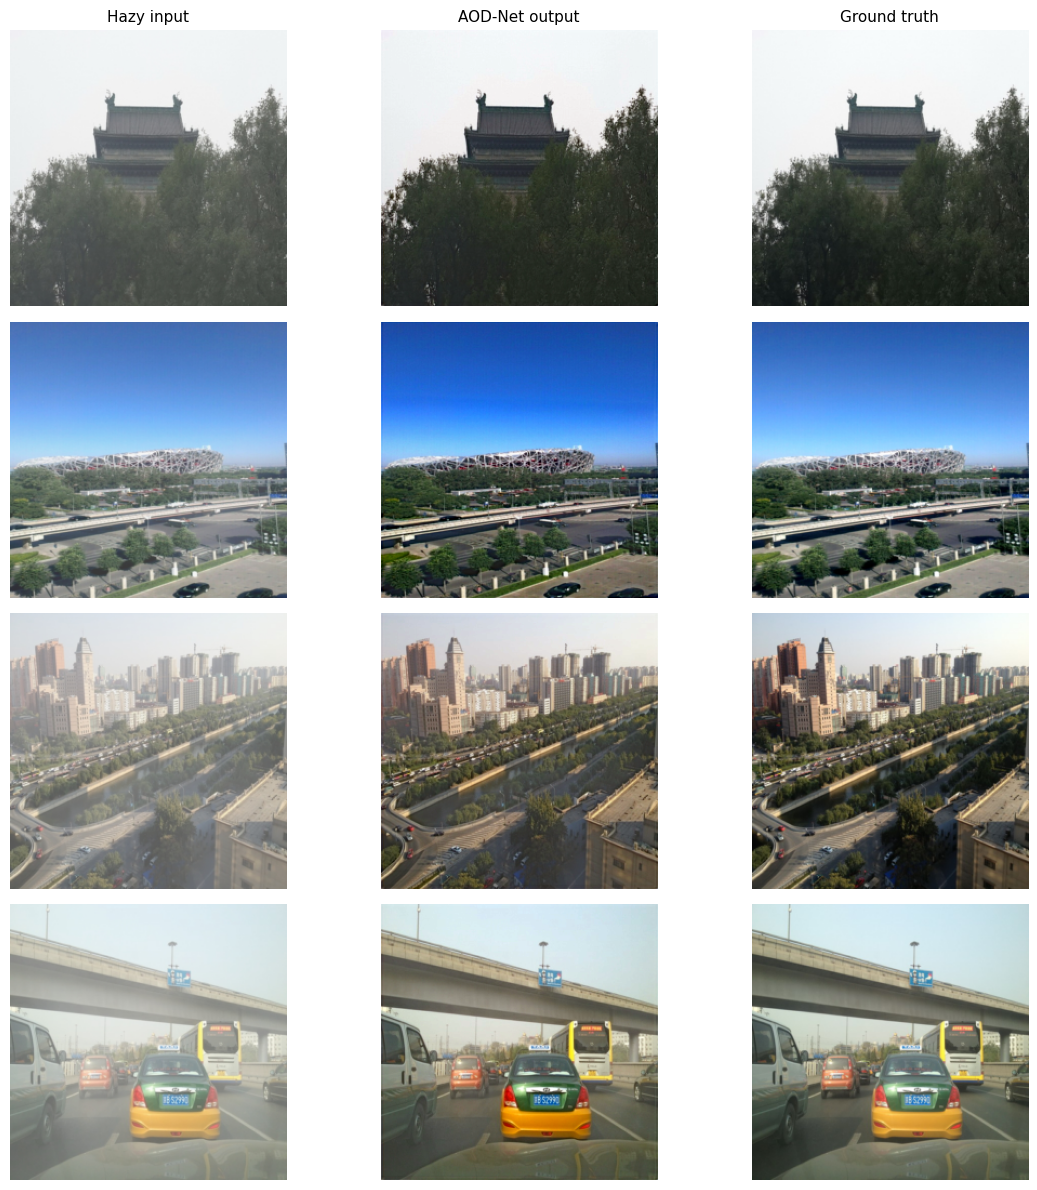

Saved: training_results.png


In [ ]:
import matplotlib.pyplot as plt

def visualize_results(model, dataset, n=4):
    device = torch.device("cuda")
    model.eval().to(device)

    fig, axes = plt.subplots(n, 3, figsize=(12, 3*n))
    axes[0][0].set_title("Hazy input",     fontsize=11)
    axes[0][1].set_title("AOD-Net output", fontsize=11)
    axes[0][2].set_title("Ground truth",   fontsize=11)

    indices = np.random.choice(len(dataset), n, replace=False)

    for row, idx in enumerate(indices):
        hazy, clear = dataset[idx]
        with torch.no_grad():
            out = model(hazy.unsqueeze(0).to(device)).squeeze().cpu().clamp(0,1)

        for col, img in enumerate([hazy, out, clear]):
            axes[row][col].imshow(img.numpy().transpose(1,2,0))
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig("training_results.png", dpi=150)
    plt.show()
    print("Saved: training_results.png")

visualize_results(model, test_dataset)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Replace the save line inside train() with this
torch.save(model.state_dict(), "aodnet_best.pth")
!cp aodnet_best.pth /content/drive/MyDrive/AODNet_data/aodnet_best.pth
print(f"  ✓ Best model saved and backed up to Drive (PSNR: {best_psnr:.2f} dB)")

NameError: name 'best_psnr' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, torch

# Create project folder on Drive
os.makedirs("/content/drive/MyDrive/AODNet_project", exist_ok=True)

# Save model weights
torch.save(model.state_dict(),
           "/content/drive/MyDrive/AODNet_project/aodnet_best.pth")

# Save full checkpoint (weights + optimizer + epoch info)
torch.save({
    'model_state_dict'    : model.state_dict(),
    'psnr'                : 22.27,
    'ssim'                : 0.9121,
    'epochs_trained'      : 20,
    'trained_on'          : 'RESIDE-6K',
    'b_value'             : model.b.item(),
}, "/content/drive/MyDrive/AODNet_project/aodnet_checkpoint.pth")

print("Saved to Drive:")
print("  aodnet_best.pth        — weights only (for inference)")
print("  aodnet_checkpoint.pth  — full checkpoint (for resuming)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive:
  aodnet_best.pth        — weights only (for inference)
  aodnet_checkpoint.pth  — full checkpoint (for resuming)


In [ ]:
# to load in other documents
#model = AODnet()
#model.load_state_dict(torch.load(
    #"/content/drive/MyDrive/AODNet_project/aodnet_best.pth"))
#model.eval()
#print("Model loaded successfully")

In [ ]:
# IDD is on Kaggle
!kaggle datasets download -d sakshaymahna/idd-segmentation \
    --path data/IDD

import zipfile
with zipfile.ZipFile("data/IDD/idd-segmentation.zip") as z:
    z.extractall("data/IDD/")

!ls data/IDD/

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDatasetMetadata


FileNotFoundError: [Errno 2] No such file or directory: 'data/IDD/idd-segmentation.zip'

In [ ]:
import numpy as np
from PIL import Image
import os, random

def synthesize_igp_fog(clear_img_np, fog_density="medium"):
    """
    Synthesizes IGP-realistic fog using atmospheric scattering:
    I(x) = J(x) * t(x) + A * (1 - t(x))

    Key differences from standard RESIDE synthesis:
    - A is grey-brown (pollution + fog mix), not pure white
    - Non-uniform transmission (fog patches, not flat layers)
    - Lower visibility range matching IGP winter data
    """
    h, w = clear_img_np.shape[:2]

    # ── IGP-specific atmospheric light (grey-brown, not white) ───
    # Pure white = [1.0, 1.0, 1.0]
    # IGP winter fog + pollution = grey-brown tint
    A_options = {
        "light"  : np.array([0.82, 0.80, 0.76]),  # light morning fog
        "medium" : np.array([0.76, 0.72, 0.65]),  # typical IGP winter
        "dense"  : np.array([0.68, 0.63, 0.55]),  # dense pollution fog
    }
    A = A_options[fog_density]
    # Add slight random variation each image
    A += np.random.uniform(-0.03, 0.03, 3)
    A  = np.clip(A, 0, 1)

    # ── Non-uniform depth map ─────────────────────────────────────
    # Roads: fog is denser at horizon, lighter near camera
    depth = np.zeros((h, w))

    # Horizon band (top 40%) — densest fog
    depth[:int(h*0.4), :] = np.random.uniform(1.2, 2.5)

    # Mid-range (40–70%) — medium fog
    depth[int(h*0.4):int(h*0.7), :] = np.random.uniform(0.6, 1.2)

    # Near-field (bottom 30%) — lightest fog
    depth[int(h*0.7):, :] = np.random.uniform(0.1, 0.5)

    # Add spatial noise for non-uniformity (fog patches)
    noise = np.random.normal(0, 0.15, (h, w))
    depth = np.clip(depth + noise, 0.05, 3.0)

    # ── Transmission map ──────────────────────────────────────────
    beta_options = {"light": 0.8, "medium": 1.2, "dense": 1.8}
    beta = beta_options[fog_density] + np.random.uniform(-0.1, 0.1)
    t = np.exp(-beta * depth)
    t = np.stack([t, t, t], axis=2)

    # ── Apply scattering model ────────────────────────────────────
    J = clear_img_np.astype(np.float32) / 255.0
    I = J * t + A * (1 - t)
    I = np.clip(I * 255, 0, 255).astype(np.uint8)
    return I


# ── Test it on one image ──────────────────────────────────────────
import matplotlib.pyplot as plt

# Use any clear image from RESIDE-6K as a test
sample_path = "data/RESIDE6K/RESIDE-6K/train/GT/1.jpg"
clear_np    = np.array(Image.open(sample_path).convert("RGB"))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(clear_np);                          axes[0].set_title("Clear")
axes[1].imshow(synthesize_igp_fog(clear_np, "light"));  axes[1].set_title("IGP Light fog")
axes[2].imshow(synthesize_igp_fog(clear_np, "medium")); axes[2].set_title("IGP Medium fog")
axes[3].imshow(synthesize_igp_fog(clear_np, "dense"));  axes[3].set_title("IGP Dense fog")
for ax in axes: ax.axis('off')
plt.suptitle("Synthetic IGP Fog — atmospheric light: grey-brown", fontsize=12)
plt.tight_layout()
plt.savefig("igp_fog_samples.png", dpi=150)
plt.show()